# AED prévia à Análise de Sentimento

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [5]:
df = pd.read_csv('../data/raw/labeled_mastodon.csv')
df

,topic,text,created_at,likes,reblogs,replies,followers,text_clean,sentiment_score,labels
0,climate,‘Playing Checkers’: Trump’s Bid to Revive Coal...,2026-02-19 00:28:04+00:00,0,0,0,160,‘playing checkers’: trump’s bid to revive coal...,0.4019,1
1,health,🧠💤 Ever feel like your #brain is still solving...,2026-02-26 22:30:00+00:00,3,7,0,1059,🧠💤 ever feel like your brain is still solving ...,0.7269,1
2,politics,It's fascinating that Manchester's Ellen Wilki...,2026-02-28 06:04:09.517000+00:00,1,2,0,76,it's fascinating that manchester's ellen wilki...,0.6249,1
3,science,P ≠ NP: Checking a solution is easy; finding i...,2026-02-28 07:39:13+00:00,0,0,0,114,p ≠ np: checking a solution is easy; finding i...,0.9217,1
4,climate,Mark Carney’s pipeline MOU with Danielle Smith...,2026-03-06 11:49:04+00:00,0,0,0,163,mark carney’s pipeline mou with danielle smith...,-0.9287,-1
...,...,...,...,...,...,...,...,...,...,...
5797,politics,#gazetadobrasil #jornalismo #noticias #politic...,2026-02-28 06:49:16.843000+00:00,0,0,0,150,gazetadobrasil jornalismo noticias politics ar...,-0.2960,-1
5798,health,Alaska Man Develops Rare 'Seal Finger' Infecti...,2026-03-05 19:06:08+00:00,0,0,0,325,alaska man develops rare 'seal finger' infecti...,0.0000,0
5799,health,"Bei meinem EKG heute morgen sagte die Ärztin, ...",2026-03-05 15:21:53+00:00,0,0,0,14,"bei meinem ekg heute morgen sagte die ärztin, ...",-0.5994,-1
5800,economy,"Alberta returning to standard, flat tax on win...",2026-03-05 20:32:05+00:00,0,0,0,37,"alberta returning to standard, flat tax on win...",0.3182,1


In [6]:
df.info(
)

<class 'pandas.DataFrame'>
RangeIndex: 5802 entries, 0 to 5801
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   topic            5802 non-null   str    
 1   text             5802 non-null   str    
 2   created_at       5802 non-null   str    
 3   likes            5802 non-null   int64  
 4   reblogs          5802 non-null   int64  
 5   replies          5802 non-null   int64  
 6   followers        5802 non-null   int64  
 7   text_clean       5802 non-null   str    
 8   sentiment_score  5802 non-null   float64
 9   labels           5802 non-null   int64  
dtypes: float64(1), int64(5), str(4)
memory usage: 453.4 KB


In [7]:
df.isnull().sum()

topic              0
text               0
created_at         0
likes              0
reblogs            0
replies            0
followers          0
text_clean         0
sentiment_score    0
labels             0
dtype: int64

In [8]:
df.isna().sum()

topic              0
text               0
created_at         0
likes              0
reblogs            0
replies            0
followers          0
text_clean         0
sentiment_score    0
labels             0
dtype: int64

In [9]:
df['topic'].value_counts()

topic
technology    984
politics      881
science       878
sports        876
climate       744
economy       722
health        717
Name: count, dtype: int64

Text(0.5, 1.0, 'frequency of topic')

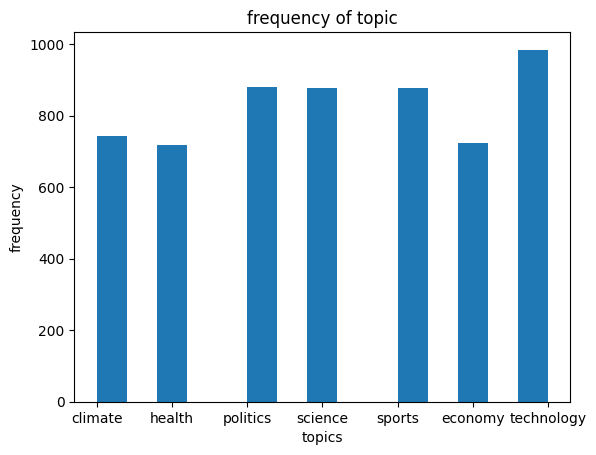

In [10]:
plt.hist(df['topic'], bins= 15)
plt.xlabel('topics')
plt.ylabel('frequency')
plt.title('frequency of topic')

In [11]:
df['followers'].max()

np.int64(174296)

In [20]:
df['likes'].max()

np.int64(254)

In [12]:
df['created_at'].min(), df['created_at'].max() 

('2026-02-18 07:12:21+00:00', '2026-03-06 15:47:45.269000+00:00')

In [13]:
df['created_at'].value_counts()

created_at
2026-02-27 12:05:02+00:00           10
2026-03-06 10:20:03+00:00           10
2026-02-26 11:05:02+00:00           10
2026-02-26 20:35:02+00:00            9
2026-02-19 12:05:02+00:00            9
                                    ..
2026-02-28 06:49:16.843000+00:00     1
2026-03-05 19:06:08+00:00            1
2026-03-05 15:21:53+00:00            1
2026-03-05 20:32:05+00:00            1
2026-02-19 08:31:43.785000+00:00     1
Name: count, Length: 5475, dtype: int64

In [14]:
df_copy = df

In [15]:
df_copy["text_length"] = df_copy["text"].str.len()
df_copy["text_length"].describe()

count    5802.000000
mean      305.597036
std       272.389890
min        25.000000
25%       179.000000
50%       272.000000
75%       375.000000
max      9922.000000
Name: text_length, dtype: float64

In [16]:
df_copy["word_count"] = df_copy["text"].apply(lambda x: len(x.split()))
df_copy["word_count"].describe()

count    5802.000000
mean       32.755774
std        41.262215
min         1.000000
25%        14.000000
50%        26.000000
75%        41.000000
max      1618.000000
Name: word_count, dtype: float64

In [21]:
df['labels'].value_counts()

labels
 1    2261
-1    1805
 0    1736
Name: count, dtype: int64

In [43]:
df.groupby("labels")["likes"].sum()

labels
-1    1765
 0     564
 1    1463
Name: likes, dtype: int64

In [44]:
df.groupby("labels")["likes"].mean()

labels
-1    0.977839
 0    0.324885
 1    0.647059
Name: likes, dtype: float64

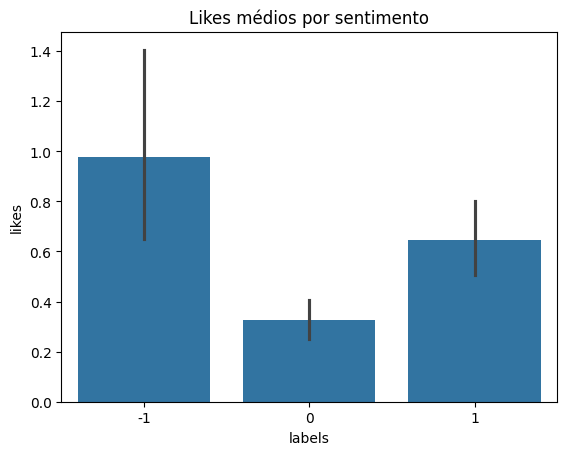

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x="labels", y="likes", data=df)

plt.title("Likes médios por sentimento")
plt.show()

In [46]:
df.groupby("topic")["likes"].sum().sort_values(ascending=False)

topic
science       1172
politics       764
health         603
climate        556
technology     420
economy        206
sports          71
Name: likes, dtype: int64

<Axes: xlabel='likes', ylabel='topic'>

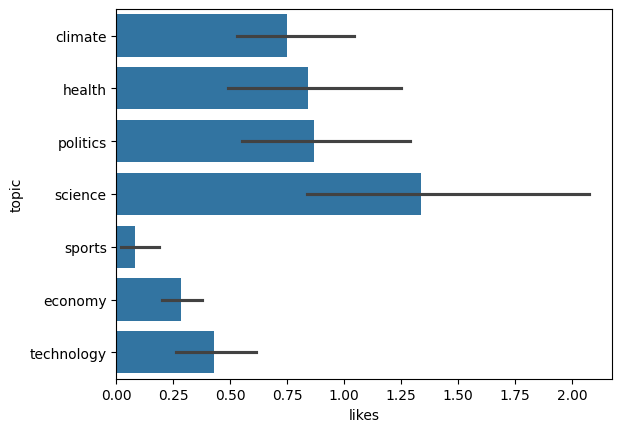

In [50]:
sns.barplot(x="likes", y="topic", data= df)


Text(0.5, 1.0, 'Frequencia de sentimentos')

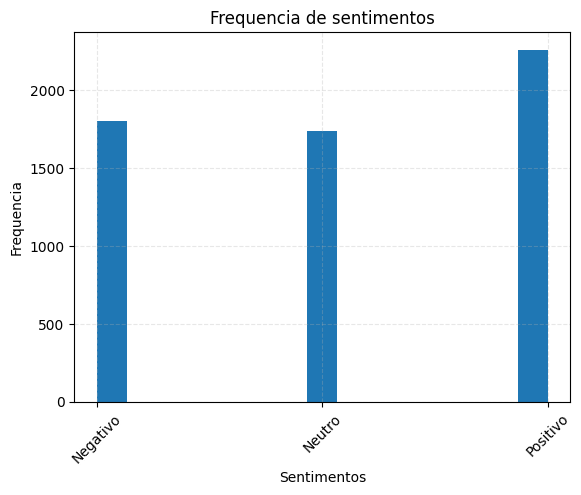

In [32]:
plt.hist(df['labels'], bins = 15)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xticks([-1, 0, 1], ["Negativo", "Neutro", "Positivo"], rotation = 45)
plt.xlabel("Sentimentos")
plt.ylabel("Frequencia")
plt.title("Frequencia de sentimentos")

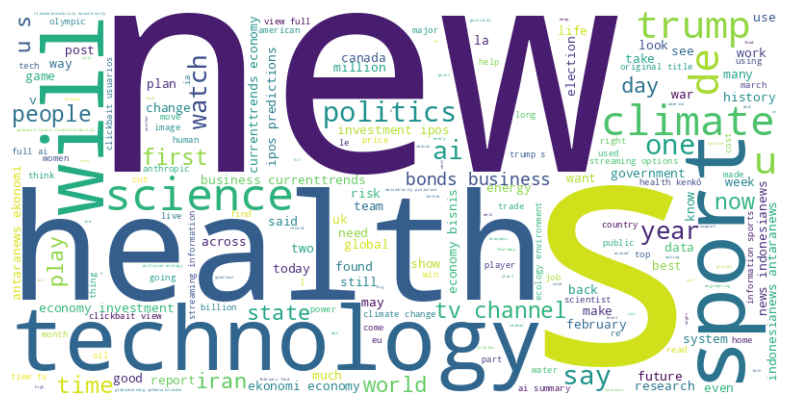

In [35]:
text = "".join(df["text_clean"])
wordcloud = WordCloud(
    width= 800,
    height= 400,
    background_color= "white"
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation= "bilinear")
plt.axis("off")
plt.show()

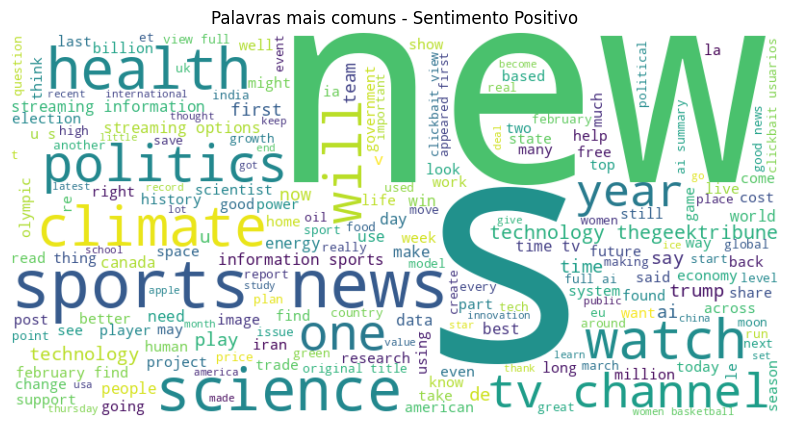

In [38]:
text_pos = " ".join(df[df["labels"] == 1]["text_clean"])

wordcloud_pos = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text_pos)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_pos, interpolation="bilinear")
plt.axis("off")
plt.title("Palavras mais comuns - Sentimento Positivo")
plt.show()

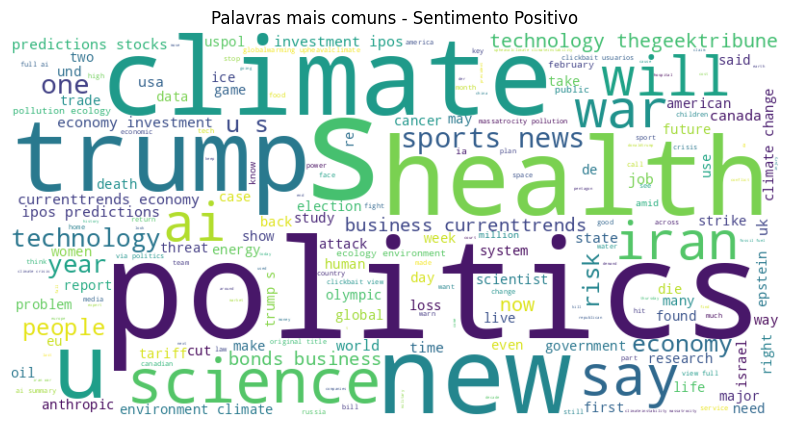

In [40]:
text_pos = " ".join(df[df["labels"] == -1]["text_clean"])

wordcloud_pos = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text_pos)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_pos, interpolation="bilinear")
plt.axis("off")
plt.title("Palavras mais comuns - Sentimento Positivo")
plt.show()

In [54]:
pd.crosstab(df['topic'], df['labels'], normalize="index")

labels,-1,0,1
topic,,,
climate,0.384409,0.243280,0.372312
economy,0.362881,0.335180,0.301939
health,0.354254,0.274756,0.370990
politics,0.444949,0.255392,0.299659
science,0.198178,0.395216,0.406606
sports,0.226027,0.206621,0.567352
technology,0.242886,0.368902,0.388211


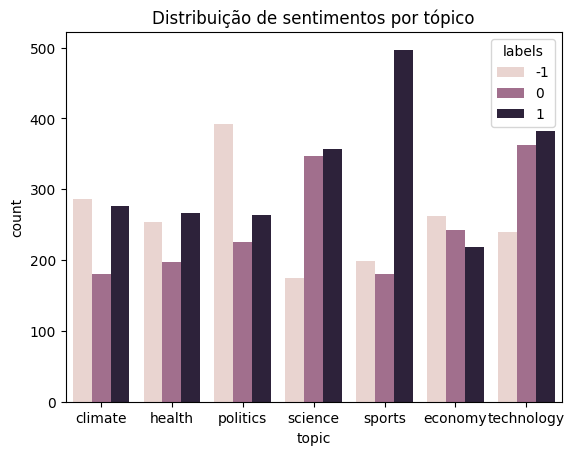

In [57]:
sns.countplot(data=df, x="topic", hue="labels")

plt.title("Distribuição de sentimentos por tópico")
plt.show()